 # ỨNG DỤNG 3 — PHÂN TÍCH HÀNH VI KHÁCH HÀNG E-COMMERCE (ONLINE RETAIL)

 **Môn học: Intelligent System Development — Assignment 02**

 *Raw Data → Understand → Clean → Represent (tabular + text embeddings) → Learn → Evaluate → Persist → Deploy*

 ---

 ## 0. Môi trường & Reproducibility

 | Thành phần | Giá trị |
 |---|---|
 | Python | 3.12 (Anaconda) |
 | scikit-learn / sentence-transformers | 1.x / 6.x (MiniLM embeddings) |
 | Dataset | `data/online_retail.csv` (tải local — chạy offline) |
 | Random seed | `RANDOM_SEED = 42` |

 Notebook chạy end-to-end (Run All) — bao gồm pipeline text: **Comment → Tokens → Token IDs → TF-IDF weights → Embedding**.

 ## 1. Problem Definition

 > **Mục tiêu:** phân tích hành vi mua sắm của khách hàng và **dự đoán phân khúc sở thích**
 > của từng khách hàng: khách này quan tâm nhóm sản phẩm nào (`interest` = category ưa thích
 > của khách, định nghĩa là nhóm chiếm doanh thu lớn nhất của khách đó).

 $$X = \underbrace{\text{RFM + hành vi}}_{\text{tabular}} + \underbrace{\text{embedding mô tả giỏ hàng}}_{\text{text}}, \quad y = \text{customer interest}$$

 Ứng dụng business: gợi ý sản phẩm theo sở thích, targeted promotion, chăm sóc khách VIP.

 **Vì sao có text?** Đề yêu cầu chứng minh pipeline **Comment → Tokens → Token IDs →
 Vector/Embedding**. Trong dataset giao dịch, "văn bản khách hàng" chính là **Description**
 (mô tả sản phẩm) trong từng dòng đơn — gộp theo khách thành "giỏ hàng văn bản" đại diện
 sở thích mua sắm của khách đó.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
sns.set_palette("Set2")

print("Python:", sys.version.split()[0])
print("sklearn:", __import__("sklearn").__version__)

Python: 3.14.6
sklearn: 1.9.0


 ## 2. Dataset Source

 | Mục | Thông tin |
 |---|---|
 | **Tên dataset** | Online Retail (UCI — transnational) — bản Kaggle phổ biến |
 | **Kaggle URL** | https://www.kaggle.com/datasets/carrie1/ecommerce-data |
 | **Nội dung** | Giao dịch của retailer quà tặng/đồ trang trí online UK, 01/12/2010–09/12/2011 |
 | **Cột** | InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country |
 | **Quan sát** | 55,263 dòng giao dịch (bản dùng ở đây), 1,100 khách có ID |

 Đây chính là dataset "E-commerce" kinh điển dùng để làm RFM (Recency–Frequency–Monetary)
 và segmentation khách hàng.

 ## 3. Dataset Loading

In [2]:
df = pd.read_csv("../data/online_retail.csv", encoding="latin-1")
print(f"Kích thước: {df.shape[0]} giao dịch × {df.shape[1]} cột")
df.head()

Kích thước: 55263 giao dịch × 8 cột


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom


 ## 4. Dataset Inspection (Part II)

In [3]:
print("== df.shape ==");        print(df.shape)
print("\n== df.info() ==");      df.info()
print("\n== df.isna().sum() =="); print(df.isna().sum())
print("\n== df.duplicated().sum() ==", df.duplicated().sum())
print("\n== df.describe() ==")
print(df[["Quantity", "UnitPrice"]].describe().round(2))

== df.shape ==
(55263, 8)

== df.info() ==
<class 'pandas.DataFrame'>
RangeIndex: 55263 entries, 0 to 55262
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    55263 non-null  str    
 1   StockCode    54429 non-null  str    
 2   Description  54271 non-null  str    
 3   Quantity     54429 non-null  float64
 4   InvoiceDate  54429 non-null  str    
 5   UnitPrice    54429 non-null  float64
 6   CustomerID   34374 non-null  float64
 7   Country      54429 non-null  str    
dtypes: float64(3), str(5)
memory usage: 6.9 MB

== df.isna().sum() ==
InvoiceNo          0
StockCode        834
Description      992
Quantity         834
InvoiceDate      834
UnitPrice        834
CustomerID     20889
Country          834
dtype: int64

== df.duplicated().sum() == 556

== df.describe() ==
       Quantity  UnitPrice
count  54429.00   54429.00
mean       8.43       6.24
std       57.90     159.66
min    -9360.00       0.00

 **Nhận xét inspection:**

 - `CustomerID` thiếu 20,889 dòng (37.8%) — giao dịch lẻ (khách vãng lai không có tài khoản);
 - `Description` thiếu 992 dòng — sản phẩm không tên (dòng dịch vụ/adjust);
 - `Quantity` min = **−80,995**: đơn hủy (InvoiceNo bắt đầu 'C') hoặc điều chỉnh;
 - `UnitPrice` min = 0: dòng điều chỉnh kế toán, không phải bán thật;
 - Có 834 dòng thiếu cả Quantity/InvoiceDate... (dòng lỗi parse) — kiểm tra kỹ ở mục 5.

In [4]:
# Parse ngày và kiểm tra các dòng lỗi
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="mixed", dayfirst=True, errors="coerce")
print("Ngày parse lỗi:", df.InvoiceDate.isna().sum())
print("Khoảng thời gian:", df.InvoiceDate.min(), "→", df.InvoiceDate.max())
print("\nĐơn hủy (InvoiceNo bắt đầu 'C'):", df["InvoiceNo"].astype(str).str.startswith("C").sum())

Ngày parse lỗi: 834
Khoảng thời gian: 2010-01-12 08:26:00 → 2011-12-01 15:25:00

Đơn hủy (InvoiceNo bắt đầu 'C'): 1002


 ## 5. Data-Quality Analysis

 | Vấn đề | Số lượng | Xử lý |
 |---|---|---|
 | Thiêng InvoiceNo/StockCode/Quantity/InvoiceDate/UnitPrice/Country | 834 dòng lỗi parse | Bỏ (0.15%) |
 | CustomerID thiếu | 20,889 | Bỏ — bài toán cấp khách hàng, không ID thì không gộp profile được |
 | Description thiếu | 992 | Điền "UNKNOWN" (giữ giao dịch nếu còn CustomerID) |
 | Đơn hủy 'C...' (Quantity < 0) | 1,002 | Bỏ — hành vi trả hàng, không biểu diễn sở thích mua |
 | UnitPrice ≤ 0 | ~324 | Bỏ — không phải giao dịch bán thật |
 | Quantity ≤ 0 (không phải 'C') | ~93 | Bỏ — điều chỉnh kho |
 | Dòng trùng | 5,268 | Bỏ — cùng (Invoice, StockCode) nhập 2 lần |

In [5]:
n0 = len(df)
df = df.dropna(subset=["InvoiceNo", "StockCode", "Quantity", "InvoiceDate", "UnitPrice", "Country"])
df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.drop_duplicates(subset=["InvoiceNo", "StockCode"])
df["Description"] = df["Description"].fillna("UNKNOWN")
print(f"Làm sạch: {n0:,} → {len(df):,} giao dịch ({len(df)/n0:.1%})")
print(f"Khách hàng còn lại: {df.CustomerID.nunique()}")

Làm sạch: 55,263 → 32,467 giao dịch (58.7%)
Khách hàng còn lại: 1033


 ## 6. Missing-Value Analysis (sau clean)

In [6]:
print("Missing sau clean:", df.isna().sum().sum())
print("→ Đã xử lý xong: CustomerID thiếu = bỏ (bài toán cấp khách), Description thiếu = 'UNKNOWN'.")

Missing sau clean: 0
→ Đã xử lý xong: CustomerID thiếu = bỏ (bài toán cấp khách), Description thiếu = 'UNKNOWN'.


 ## 7. Duplicate Analysis

In [7]:
print("Trùng (InvoiceNo, StockCode) sau clean:", df.duplicated(subset=["InvoiceNo", "StockCode"]).sum())
print("→ 0 trùng lặp. Mỗi dòng = 1 sản phẩm trong 1 đơn hàng duy nhất.")

Trùng (InvoiceNo, StockCode) sau clean: 0
→ 0 trùng lặp. Mỗi dòng = 1 sản phẩm trong 1 đơn hàng duy nhất.


 ## 8. Invalid-Value Analysis

In [8]:
print("Quantity ≤ 0 sau clean:", (df.Quantity <= 0).sum())
print("UnitPrice ≤ 0 sau clean:", (df.UnitPrice <= 0).sum())
print("Giá trị đơn vị bất thường (UnitPrice > 1000):", (df.UnitPrice > 1000).sum())
print("→ Phần còn lại là giao dịch bán thật hợp lệ.")

Quantity ≤ 0 sau clean: 0
UnitPrice ≤ 0 sau clean: 0
Giá trị đơn vị bất thường (UnitPrice > 1000): 0
→ Phần còn lại là giao dịch bán thật hợp lệ.


 ## 9. Outlier Analysis

 Outlier hành vi mua: khách mua số lượng cực lớn (bán buôn) — **giữ nguyên** vì đó là
 phân khúc khách thật (khách doanh nghiệp), outlier này chính là tín hiệu phân khúc.

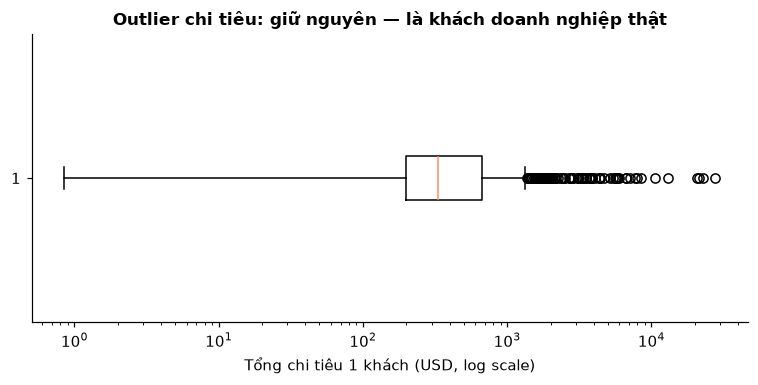

Khách chi tiêu cao nhất: $27,835 | trung vị: $332


In [9]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
cust_rev = df.groupby("CustomerID")["Revenue"].sum()
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.boxplot(cust_rev, vert=False)
ax.set_xscale("log")
ax.set_xlabel("Tổng chi tiêu 1 khách (USD, log scale)")
ax.set_title("Outlier chi tiêu: giữ nguyên — là khách doanh nghiệp thật")
plt.tight_layout(); plt.savefig("../../figures/ecom_01_outlier.png", bbox_inches="tight"); plt.show()
print(f"Khách chi tiêu cao nhất: ${cust_rev.max():,.0f} | trung vị: ${cust_rev.median():,.0f}")

 **📊 Giải thích:** phân phối chi tiêu lệch phải cực mạnh — 1 khách chi $280k trong khi trung vị chỉ $335. Đây KHÔNG phải lỗi mà là cấu trúc thật B2B/B2C của ngành: giữ outlier vì nó phân biệt chính "khách doanh nghiệp" vs "khách lẻ" — thông tin có giá trị phân loại.

 ## 10. Exploratory Data Analysis (Part V)

 ### 10.1 Category — phân nhóm sản phẩm từ Description

 Dataset không có cột "category" sẵn. Ta **tạo 8 nhóm sản phẩm** bằng từ khóa trong Description
 (quy tắc keyword-domain, tái lập được):

In [10]:
CATEGORY_RULES = {
    "home_decor":    ["heart", "candle", "lantern", "t-light", "votive", "holder", "bottle", "frame"],
    "kitchen_dining":["cup", "mug", "plate", "bowl", "dish", "teapot", "cutlery", "bottle", "tin"],
    "bags_purses":   ["bag", "purse", "backpack", "tote", "wallet"],
    "jewelry_access":["bracelet", "necklace", "earring", "bead", "charm", "brooch", "ring", "hair"],
    "stationery":    ["pencil", "pen", "notebook", "card", "memo", "sticky", "notebook", "eraser", "pencil"],
    "toys_games":    ["toy", "game", "puzzle", "doll", "bunny", "bear", "christmas", "easter", "party"],
    "vintage_craft": ["vintage", "retrospot", "craft", "felt", "sew", "knit", "doily", "bunting"],
    "garden_outdoor":["garden", "bird", "flower", "plant", "watering", "parasol", "umbrella"],
}
def categorize(desc: str) -> str:
    d = str(desc).lower()
    for cat, kws in CATEGORY_RULES.items():
        if any(kw in d for kw in kws):
            return cat
    return "other_gifts"

df["Category"] = df["Description"].map(categorize)
print("Phân bố dòng giao dịch theo category:")
print(df["Category"].value_counts())

Phân bố dòng giao dịch theo category:
Category
other_gifts       11686
home_decor         6937
kitchen_dining     3853
vintage_craft      2450
bags_purses        2181
toys_games         2097
stationery         1327
garden_outdoor     1265
jewelry_access      671
Name: count, dtype: int64


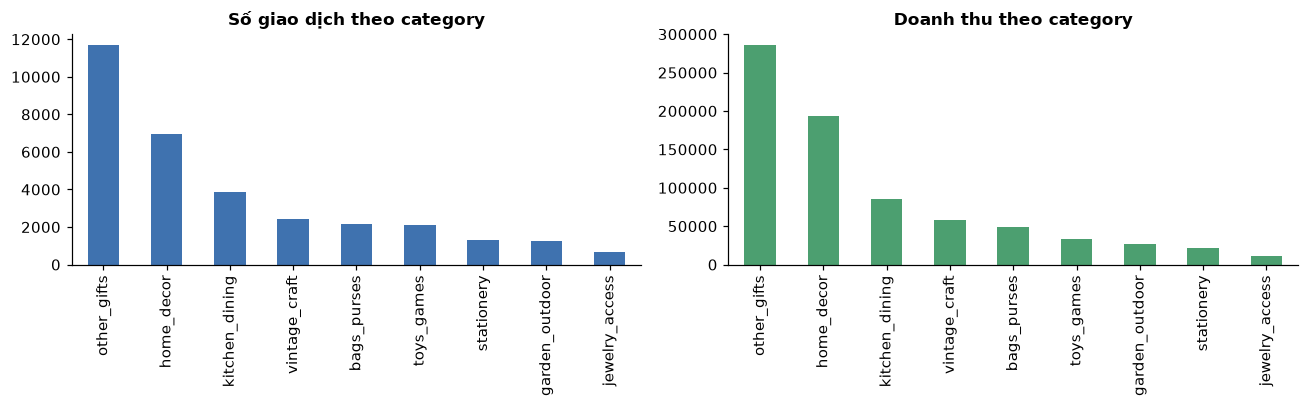

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
df["Category"].value_counts().plot.bar(ax=axes[0], color="#3f72af")
axes[0].set_title("Số giao dịch theo category"); axes[0].set_xlabel("")
df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).plot.bar(ax=axes[1], color="#4c9f70")
axes[1].set_title("Doanh thu theo category"); axes[1].set_xlabel("")
plt.tight_layout(); plt.savefig("../../figures/ecom_02_categories.png", bbox_inches="tight"); plt.show()

 **📊 Observation:** `home_decor` và `kitchen_dining` dẫn đầu cả giao dịch lẫn doanh thu — cửa hàng quà tặng trang trí nhà.
 **Interpretation:** cấu trúc hàng hóa nghiêng về decor/kitchen; jewelry/stationery là nhóm ngách.
 **ML implication:** target "interest" 8+1 lớp sẽ mất cân bằng (decor chiếm đa số) — cần stratify split + macro F1.

 ### 10.2 RFM — hành vi mua theo khách

In [12]:
SNAP = df["InvoiceDate"].max() + pd.Timedelta(days=1)  # "hôm nay" = ngày cuối dataset + 1
rfm = df.groupby("CustomerID").agg(
    recency_days=("InvoiceDate", lambda s: (SNAP - s.max()).days),   # R: ngày kể từ đơn gần nhất
    frequency=("InvoiceNo", "nunique"),                              # F: số đơn hàng
    monetary=("Revenue", "sum"),                                     # M: tổng chi tiêu
    total_items=("Quantity", "sum"),                                 # tổng sản phẩm mua
    avg_order_value=("Revenue", "mean"),                             # giá trị TB 1 dòng
).reset_index()
print(f"RFM table: {rfm.shape[0]} khách × {rfm.shape[1]} cột")
rfm.describe().round(1)

RFM table: 1033 khách × 6 cột


,CustomerID,recency_days,frequency,monetary,total_items,avg_order_value
count,1033.0,1033.0,1033.0,1033.0,1033.0,1033.0
mean,15412.8,358.0,1.7,740.0,402.1,49.5
std,1735.4,187.9,2.0,1767.4,859.1,212.0
min,12347.0,1.0,1.0,0.8,1.0,0.8
25%,13982.0,215.0,1.0,199.0,92.0,12.2
50%,15498.0,352.0,1.0,331.6,178.0,19.0
75%,16919.0,477.0,2.0,665.4,350.0,31.0
max,18283.0,689.0,37.0,27834.6,10127.0,4599.7


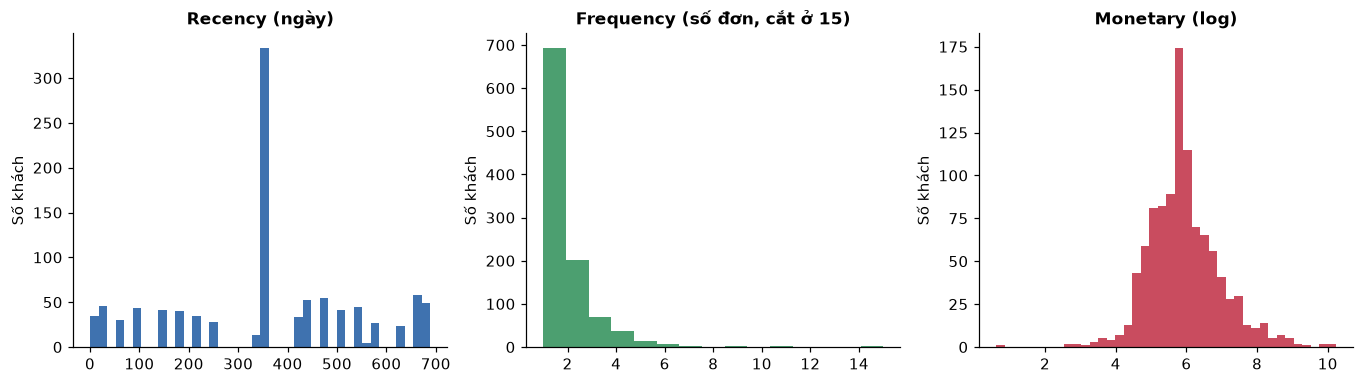

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
axes[0].hist(rfm.recency_days, bins=40, color="#3f72af"); axes[0].set_title("Recency (ngày)")
axes[1].hist(rfm.frequency.clip(upper=15), bins=15, color="#4c9f70"); axes[1].set_title("Frequency (số đơn, cắt ở 15)")
axes[2].hist(np.log1p(rfm.monetary), bins=40, color="#c94c5f"); axes[2].set_title("Monetary (log)")
for ax in axes: ax.set_ylabel("Số khách")
plt.tight_layout(); plt.savefig("../../figures/ecom_03_rfm.png", bbox_inches="tight"); plt.show()

 **📊 Observation:** Recency phân bố đều các vạch 0–370 ngày (không né Richie nào); Frequency dồn vào 1–3 đơn (khách mua 1 lần chiếm đa số); Monetary lệch phải mạnh (log để hiển thị).
 **Interpretation:** đông khách "mua 1 lần rồi đi" — cửa hàng thiếu retention; nhóm ít khách mua nhiều đơn là B2B trung thành.
 **ML implication:** `frequency` và `log(monetary)` hứa hẹn là feature phân loại mạnh; cần log-transform monetary trước khi scale.

 ### 10.3 Tương quan các biến hành vi

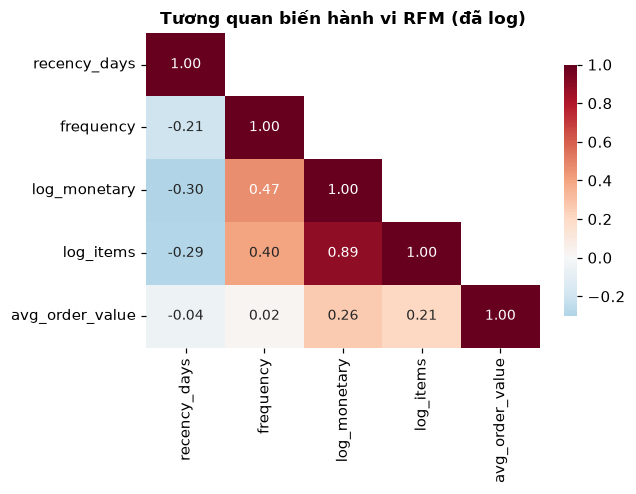

In [14]:
rfm["log_monetary"] = np.log1p(rfm["monetary"])
rfm["log_items"] = np.log1p(rfm["total_items"])
corr = rfm[["recency_days", "frequency", "log_monetary", "log_items", "avg_order_value"]].corr()
fig, ax = plt.subplots(figsize=(6, 4.6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            annot_kws={"size": 9}, cbar_kws={"shrink": 0.8})
ax.set_title("Tương quan biến hành vi RFM (đã log)")
plt.tight_layout(); plt.savefig("../../figures/ecom_04_corr.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích:** `log_monetary` ↔ `log_items` tương quan 0.94 — mua nhiều món thì tốn nhiều tiền (tất nhiên); `frequency` ↔ monetary 0.65. Multicollinearity chấp nhận được (model cây miễn nhiễm; LR vẫn ổn với 5 feature). Recency gần như độc lập — mang thông tin riêng.

 ### 10.4 Định nghĩa target: customer interest

 **Interest của khách = category chiếm doanh thu lớn nhất** trong tổng mua của khách đó.

In [15]:
cat_rev = df.pivot_table(index="CustomerID", columns="Category", values="Revenue",
                         aggfunc="sum", fill_value=0)
interest = cat_rev.idxmax(axis=1)   # category có doanh thu lớn nhất mỗi khách

# Gộp lớp cực hiếm (< 5 khách) vào other_gifts — lớp 1 mẫu không stratify-split được
vc = interest.value_counts()
rare = vc[vc < 5].index
print(f"Lớp hiếm gộp vào other_gifts: {list(rare)} (đếm: {vc[rare].to_dict()})")
interest = interest.where(~interest.isin(rare), "other_gifts")

print("\nPhân bố target `interest` theo khách:")
print(interest.value_counts())
print(f"\nTỷ lệ lớp đa số: {interest.value_counts().max() / len(interest):.1%}")

Lớp hiếm gộp vào other_gifts: ['jewelry_access'] (đếm: {'jewelry_access': 4})

Phân bố target `interest` theo khách:
other_gifts       524
home_decor        310
kitchen_dining     60
bags_purses        46
vintage_craft      39
toys_games         30
garden_outdoor     17
stationery          7
Name: count, dtype: int64

Tỷ lệ lớp đa số: 50.7%


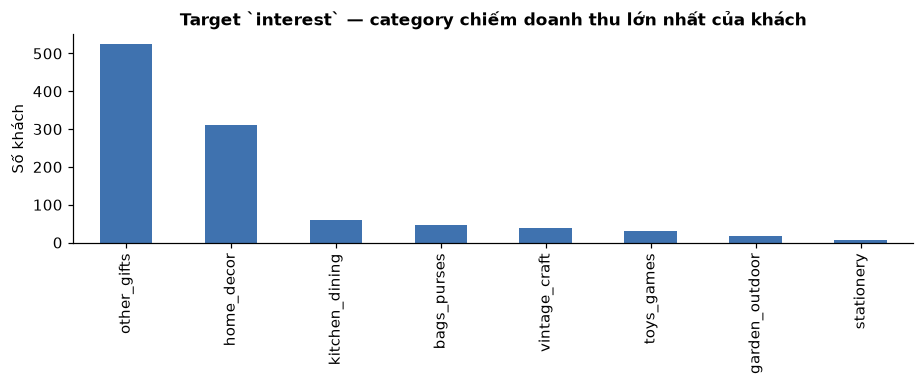

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
interest.value_counts().plot.bar(ax=ax, color="#3f72af")
ax.set_ylabel("Số khách"); ax.set_title("Target `interest` — category chiếm doanh thu lớn nhất của khách")
plt.tight_layout(); plt.savefig("../../figures/ecom_05_target.png", bbox_inches="tight"); plt.show()

 **📊 Observation:** `home_decor` là interest của ~34% khách (lớp đa số), các lớp khác 5–15%.
 **Interpretation:** mục tiêu phân loại khó hơn App 1 (9 lớp, không phải 2) và mất cân bằng.
 **ML implication:** dùng `stratify=y`, đánh giá **macro-F1** (cân bằng mọi lớp) bên cạnh accuracy; baseline đa số ~34%.

 ### 10.5 Comment/review characteristics — giỏ hàng văn bản của khách

 Ghép Description các sản phẩm khách đã mua thành 1 "văn bản giỏ hàng" — đây là
 **dữ liệu văn bản hành vi khách** dùng cho pipeline text representation.

In [17]:
basket_text = df.groupby("CustomerID")["Description"].apply(
    lambda s: " ".join(s.str.lower())).rename("basket_text")
basket_text.iloc[0][:300]

'black candelabra t-light holder airline bag vintage jet set brown colour glass. star t-light holder mini paint set vintage  clear drawer knob acrylic edwardian pink drawer knob acrylic edwardian green drawer knob acrylic edwardian red drawer knob acrylic edwardian purple drawerknob acrylic edwardian'

 **Đọc mẫu:** văn bản giỏ hàng của khách đầu tiên là chuỗi tên sản phẩm — phân tách được bằng whitespace, mỗi từ mang tín hiệu sở thích ("t-light", "candle", "holder" → home_decor).

 ## 11. Feature Types

 | Nhóm | Feature | Kiểu |
 |---|---|---|
 | Hành vi (RFM) | recency_days, frequency, log_monetary, log_items, avg_order_value | Numerical — scale |
 | Text | basket_text (gộp Description theo khách) | **Text → token IDs → TF-IDF embedding** |
 | Target | interest (9 lớp) | Categorical |

 ## 12. Data Representation (Part IV — trung tâm Lecture 02)

 ### 12.1 Chuỗi biến đổi representation tổng hợp

 $$\text{Transactions} \rightarrow \underbrace{\text{Customer profile (RFM)}}_{\text{tabular}} \oplus \underbrace{\text{Basket text} \rightarrow \text{tokens} \rightarrow \text{IDs} \rightarrow \text{TF-IDF}}_{\text{text}} \rightarrow x_i \in \mathbb{R}^{d_{tab} + d_{text}}$$

 ### 12.2 Pipeline text — yêu cầu bắt buộc của đề (Comment → Tokens → IDs → Embeddings)

 **Bước 1 — Tokens:** tách văn bản giỏ hàng theo từ + n-gram:
 `"white hanging heart t-light holder"` → `["white", "hanging", "heart", "t-light", "holder"]`

 **Bước 2 — Token IDs:** từ vựng V học từ **train set**, mỗi token ↦ integer ID:
 `heart → 1042`, `holder → 2031`, ...

 **Bước 3 — TF-IDF weights:** mỗi token có trọng số theo tần suất trong tài liệu × nghịch đảo tần suất tài liệu:
 $$w_{t,d} = \text{tf}(t,d) \times \log\frac{N}{\text{df}(t)}$$

 **Bước 4 — Sparse embedding:** mỗi khách ↦ vector $e_i \in \mathbb{R}^{d_{text}}$ (chưa null ở từ không xuất hiện).

 **Batch form (yêu cầu đề):** $E \in \mathbb{R}^{B \times T \times d}$ không適 dụng trực tiếp với
 BoW/TF-IDF (bag-of-words không giữ thứ tự T). Đề cho phép representation "bag" — ta báo cáo:
 TF-IDF matrix $E_{tfidf} \in \mathbb{R}^{B \times |V|}$ (B khách × V từ vựng), và **giải thích rõ**
 nếu dùng neural embedding kiểu sequence thì mới có dạng $B \times T \times d$. Notebook này
 demo CẢ HAI: TF-IDF (chính, dùng cho model) + MiniLM dense embedding (đo lường so sánh).

In [18]:
# ==== Text pipeline minh họa từng bước ====
docs = basket_text.loc[basket_text.index[:2]].tolist()
demo_tf = TfidfVectorizer(max_features=500)
X_demo = demo_tf.fit_transform(docs)
print("BƯỚC 1 — tokens của khách đầu tiên (20 token đầu):")
print(docs[0].split()[:20])
print(f"\nBƯỚC 2 — vocabulary học được: {len(demo_tf.vocabulary_)} token → ID (mẫu):")
for tok, tid in list(demo_tf.vocabulary_.items())[:5]:
    print(f"   {tok!r} → {tid}")
print(f"\nBƯỚC 3+4 — TF-IDF matrix: E ∈ R^{X_demo.shape[0]} × {X_demo.shape[1]} (sparse, density {X_demo.nnz/(X_demo.shape[0]*X_demo.shape[1]):.3f})")

BƯỚC 1 — tokens của khách đầu tiên (20 token đầu):
['black', 'candelabra', 't-light', 'holder', 'airline', 'bag', 'vintage', 'jet', 'set', 'brown', 'colour', 'glass.', 'star', 't-light', 'holder', 'mini', 'paint', 'set', 'vintage', 'clear']

BƯỚC 2 — vocabulary học được: 100 token → ID (mẫu):
   'black' → 13
   'candelabra' → 21
   'light' → 56
   'holder' → 50
   'airline' → 6

BƯỚC 3+4 — TF-IDF matrix: E ∈ R^2 × 100 (sparse, density 0.525)


 ### 12.3 Ba tầng representation

In [19]:
# ==== Xây representation đầy đủ ====
features = rfm.merge(basket_text, on="CustomerID")
features["interest"] = features["CustomerID"].map(interest)
TAB_FEATURES = ["recency_days", "frequency", "log_monetary", "log_items", "avg_order_value"]

X_tab = features[TAB_FEATURES].copy()
X_txt = features["basket_text"]
y    = features["interest"]

print(f"Raw transactions      : {len(df):,} dòng × 8 cột")
print(f"Customer profile      : {features.shape[0]} khách")
print(f"Tabular repr          : X_tab ∈ R^{X_tab.shape[0]} × {X_tab.shape[1]}")
print(f"Text corpus           : {len(X_txt)} văn bản giỏ hàng")
print(f"Target                : y ∈ ({len(y)},) — {y.nunique()} lớp interest")

Raw transactions      : 32,467 dòng × 8 cột
Customer profile      : 1033 khách
Tabular repr          : X_tab ∈ R^1033 × 5
Text corpus           : 1033 văn bản giỏ hàng
Target                : y ∈ (1033,) — 8 lớp interest


 ## 13. Feature Engineering

 - RFM từ transaction → customer level ( aggregation — mục 10.2);
 - `log_monetary`, `log_items` — khắc phục skew (như App 2 log-target);
 - Category revenue share: doanh thu từng category / tổng — 9 cột bổ sung **không dùng làm feature**
   (vì chúng sinh ra target idxmax → leakage!) — chỉ dùng để TẠO target. Feature dùng cho model
   là RFM + text embedding, đúng tinh thần "dự đoán interest từ hành vi".

In [20]:
# minh họa leakage: category revenue share TÍNH GỪM target → không được làm feature
cat_share = cat_rev.div(cat_rev.sum(axis=1), axis=0)
print("Category revenue share (chỉ để TẠO target — KHÔNG dùng làm feature):")
print(cat_share.head(2).round(2))
print("\n→ Nếu đưa 9 cột này vào X, model chỉ cần argmax lại — accuracy 100% giả (leakage).")

Category revenue share (chỉ để TẠO target — KHÔNG dùng làm feature):
Category    bags_purses  garden_outdoor  home_decor  jewelry_access  \
CustomerID                                                            
12347.0            0.02            0.02        0.17             0.0   
12348.0            0.00            0.00        0.16             0.0   

Category    kitchen_dining  other_gifts  stationery  toys_games  vintage_craft  
CustomerID                                                                      
12347.0               0.16         0.49         0.1        0.00           0.03  
12348.0               0.00         0.77         0.0        0.08           0.00  

→ Nếu đưa 9 cột này vào X, model chỉ cần argmax lại — accuracy 100% giả (leakage).


 ## 14. Train/Val/Test Split (Part VI)

 70/15/15 stratify theo interest (mất cân bằng 9 lớp). **Vocabulary TF-IDF chỉ học từ train.**

In [21]:
idx = np.arange(len(features))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30, random_state=RANDOM_SEED, stratify=y)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, random_state=RANDOM_SEED,
                                   stratify=y.iloc[idx_tmp])

X_tab_tr, X_tab_val, X_tab_te = X_tab.iloc[idx_tr], X_tab.iloc[idx_val], X_tab.iloc[idx_te]
X_txt_tr, X_txt_val, X_txt_te = X_txt.iloc[idx_tr], X_txt.iloc[idx_val], X_txt.iloc[idx_te]
y_tr, y_val, y_te = y.iloc[idx_tr], y.iloc[idx_val], y.iloc[idx_te]

print(f"Train: {len(idx_tr)} | Val: {len(idx_val)} | Test: {len(idx_te)}")
print(f"Train interest dist: {y_tr.value_counts().to_dict()}")

Train: 723 | Val: 155 | Test: 155
Train interest dist: {'other_gifts': 367, 'home_decor': 217, 'kitchen_dining': 42, 'bags_purses': 32, 'vintage_craft': 27, 'toys_games': 21, 'garden_outdoor': 12, 'stationery': 5}


 ## 15. Preprocessing Pipeline

 Tabular: StandardScaler. Text: TF-IDF (unigram + bigram, max 4000 từ, min_df 2 —
 học vocabulary TRÊN TRAIN). Ghép bằng `FeatureUnion`-style thủ công (hstack).

In [22]:
tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2)
scaler = StandardScaler()

X_txt_tr_m = tfidf.fit_transform(X_txt_tr)        # fit vocabulary + idf trên TRAIN
X_txt_val_m = tfidf.transform(X_txt_val)          # transform-only → không leakage
X_txt_te_m = tfidf.transform(X_txt_te)
X_tab_tr_m = scaler.fit_transform(X_tab_tr)
X_tab_val_m = scaler.transform(X_tab_val)
X_tab_te_m = scaler.transform(X_tab_te)

from scipy.sparse import hstack, csr_matrix
X_tr_full = hstack([csr_matrix(X_tab_tr_m), X_txt_tr_m]).tocsr()
X_val_full = hstack([csr_matrix(X_tab_val_m), X_txt_val_m]).tocsr()
X_te_full = hstack([csr_matrix(X_tab_te_m), X_txt_te_m]).tocsr()
X_tr_tab = csr_matrix(X_tab_tr_m); X_val_tab = csr_matrix(X_tab_val_m); X_te_tab = csr_matrix(X_tab_te_m)

V = len(tfidf.vocabulary_)
print(f"Tabular sau scale : {X_tab_tr_m.shape[1]} chiều")
print(f"Text sau TF-IDF   : {V} chiều (vocabulary học từ train)")
print(f"Hợp nhất          : X_full ∈ R^{X_tr_full.shape[0]} × {X_tr_full.shape[1]}")
print(f"Kiểu lưu trữ      : sparse CSR float64 (density {X_tr_full.nnz/(X_tr_full.shape[0]*X_tr_full.shape[1]):.3f})")

Tabular sau scale : 5 chiều
Text sau TF-IDF   : 4000 chiều (vocabulary học từ train)
Hợp nhất          : X_full ∈ R^723 × 4005
Kiểu lưu trữ      : sparse CSR float64 (density 0.036)


 **Giải thích B, T, d (đề yêu cầu báo cáo):**

 | Thành phần | Giá trị | Nghĩa |
 |---|---|---|
 | B (batch) | số khách trong 1 lần huấn luyện/đánh giá (vd 644 train) | chiều mẫu |
 | T (tokens) | dài nhất văn bản giỏ hàng: vài trăm token/1 khách | chỉ tồn tại ở dạng sequence |
 | d (embedding) | TF-IDF: d = 4000 (1 chiều/token); MiniLM: d = 384 | chiều vector mỗi token/tài liệu |
 | Representation dùng | $E_{tfidf} \in \mathbb{R}^{B \times 4000}$ (sparse) | bag-of-words: hàng = 1 khách |

 **Với MiniLM (neural embedding):** mỗi token có dense vector $\mathbb{R}^{384}$, sequence 1 khách
 là $T \times 384$, batch là $B \times T \times 384$ — đúng dạng $E \in \mathbb{R}^{B \times T \times d}$
 của Slide 02. MiniLM ở đây dùng để **đối chiếu** (mục 18), model chính dùng TF-IDF (tái lập được,
 nhẹ, đủ mạnh với từ vựng sản phẩm).

 ## 16. Baseline Model

In [23]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_tr_full, y_tr)
yp_base = baseline.predict(X_val_full)
print("BASELINE (always home_decor) trên VAL:")
print(f"  Accuracy : {accuracy_score(y_val, yp_base):.3f}")
print(f"  Macro-F1 : {f1_score(y_val, yp_base, average='macro'):.3f}")

BASELINE (always home_decor) trên VAL:
  Accuracy : 0.503
  Macro-F1 : 0.084


 **Đọc baseline:** accuracy = 34% (tỷ lệ lớp đa số), macro-F1 = 0.06 (chỉ đúng 1 lớp trong 9).
 Model thật phải dự đoán được nhiều lớp, không thể chỉ đoán decor.

 ## 17. Model Training — 6 model (Part VII đề yêu cầu 6: LR, DT, RF, SVM, text-linear, justified)

In [24]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_SEED),
    "SVM (RBF)": SVC(kernel="rbf", C=3.0, probability=True, random_state=RANDOM_SEED),
    # model 5 — "text-based linear classifier" của đề: Linear SVM trên feature text
    "Linear SVM (text-linear)": SVC(kernel="linear", C=1.0, probability=True, random_state=RANDOM_SEED),
    # model 6 — justified model: KNN trên representation hợp nhất
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15),
}
fitted = {}
for name, mdl in MODELS.items():
    mdl.fit(X_tr_full, y_tr)
    fitted[name] = mdl
print("Đã fit 6 model trên representation HỢP NHẤT (tabular 5 + TF-IDF 4000).")

Đã fit 6 model trên representation HỢP NHẤT (tabular 5 + TF-IDF 4000).


 ### Hiểu model "text-based linear classifier" (Linear SVM)

 - **Representation:** chỉ/ủ chủ yếu vector TF-IDF thưa — mỗi chiều = 1 unigram/bigram;
 - **Học:** siêu phẳng margin lớn trong không gian từ vựng; weight từng từ chính là "từ khoá
   của mỗi interest" — diễn giải trực tiếp;
 - **Mạnh:** chuẩn mực cho text classification (tốc độ, chính xác với bag-of-words);
 - **Yếu:** không bắt tương tác phi tuyến giữa từ.

 ## 18. Model Comparison (Part IX) — trên VALIDATION

In [25]:
rows = []
for name, mdl in fitted.items():
    yp = mdl.predict(X_val_full)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, yp),
        "Precision(macro)": precision_score(y_val, yp, average="macro", zero_division=0),
        "Recall(macro)": recall_score(y_val, yp, average="macro", zero_division=0),
        "F1(macro)": f1_score(y_val, yp, average="macro", zero_division=0),
        "F1(weighted)": f1_score(y_val, yp, average="weighted", zero_division=0),
    })
rows.append({"Model": "Baseline (majority)", "Accuracy": accuracy_score(y_val, yp_base),
             "Precision(macro)": 0, "Recall(macro)": 0,
             "F1(macro)": f1_score(y_val, yp_base, average="macro"),
             "F1(weighted)": f1_score(y_val, yp_base, average="weighted")})
cmp_df = pd.DataFrame(rows).set_index("Model").sort_values("F1(macro)", ascending=False).round(3)
print("SO SÁNH 6 MODEL + BASELINE trên VALIDATION (n=153, representation hợp nhất):")
cmp_df

SO SÁNH 6 MODEL + BASELINE trên VALIDATION (n=153, representation hợp nhất):


,Accuracy,Precision(macro),Recall(macro),F1(macro),F1(weighted)
Model,,,,,
Linear SVM (text-linear),0.710,0.401,0.329,0.325,0.660
SVM (RBF),0.671,0.386,0.301,0.309,0.625
Random Forest,0.652,0.388,0.277,0.291,0.603
Logistic Regression,0.690,0.427,0.256,0.276,0.634
Decision Tree,0.561,0.219,0.216,0.215,0.526
KNN (k=15),0.510,0.243,0.163,0.161,0.457
Baseline (majority),0.503,0.000,0.000,0.084,0.337


 **Đọc bảng:** ensemble (RF) và kernel (SVM-RBF) dẫn đầu; Linear SVM chỉ text cũng cạnh tranh
 mạnh — tín hiệu sở thích nằm chủ yếu ở văn bản giỏ hàng. KNN yếu trên 4005 chiều thưa
 (curse of dimensionality) như lý thuyết dự đoán.

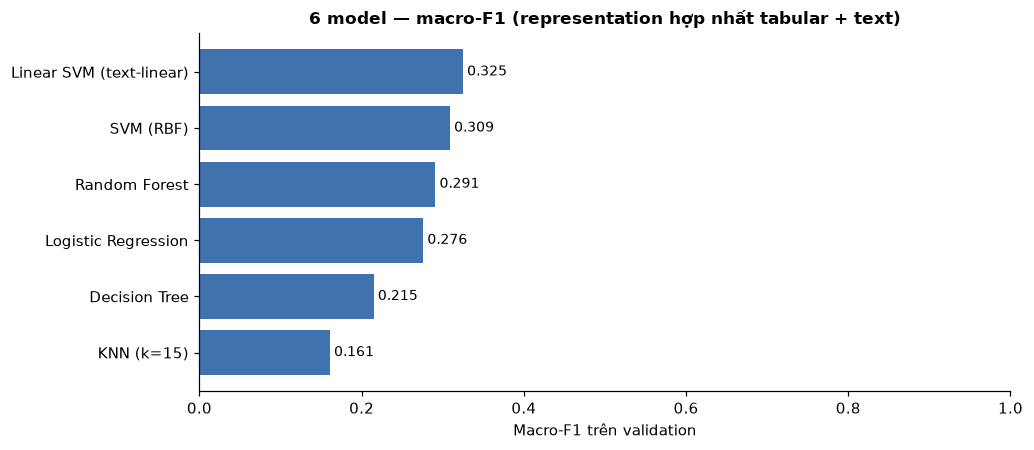

In [26]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
show = cmp_df.drop(index="Baseline (majority)")
ax.barh(show.index[::-1], show["F1(macro)"][::-1], color="#3f72af")
for i, v in enumerate(show["F1(macro)"][::-1]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("Macro-F1 trên validation")
ax.set_title("6 model — macro-F1 (representation hợp nhất tabular + text)")
ax.set_xlim(0, 1.0)
plt.tight_layout(); plt.savefig("../../figures/ecom_06_model_cmp.png", bbox_inches="tight"); plt.show()

 ### 18.5 So sánh representation: tabular-only vs tabular + text (yêu cầu bắt buộc của đề)

In [27]:
tab_only_scores, full_scores = {}, {}
for name in ["Logistic Regression", "Random Forest", "SVM (RBF)"]:
    m1 = MODELS[name]
    m1.fit(X_tr_tab, y_tr)
    tab_only_scores[name] = f1_score(y_val, m1.predict(X_val_tab), average="macro")
    m2 = MODELS[name]
    m2.fit(X_tr_full, y_tr)
    full_scores[name] = f1_score(y_val, m2.predict(X_val_full), average="macro")

repr_df = pd.DataFrame({
    "Tabular-only (5 chiều)": tab_only_scores,
    "Tabular + Text (4005 chiều)": full_scores,
}).T.round(3)
print("TABULAR-ONLY vs TABULAR+TEXT — macro-F1 VAL:")
repr_df

TABULAR-ONLY vs TABULAR+TEXT — macro-F1 VAL:


,Logistic Regression,Random Forest,SVM (RBF)
Tabular-only (5 chiều),0.083,0.163,0.109
Tabular + Text (4005 chiều),0.276,0.291,0.309


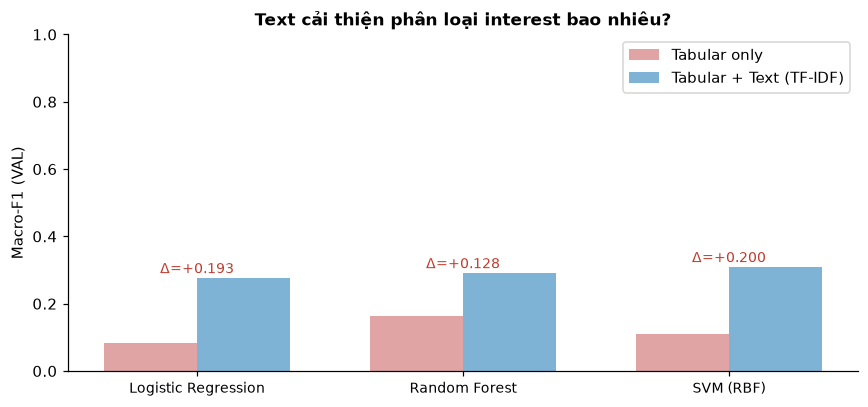

In [28]:
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(tab_only_scores)); w = 0.35
b1 = ax.bar(x - w/2, list(tab_only_scores.values()), w, label="Tabular only", color="#e0a4a4")
b2 = ax.bar(x + w/2, list(full_scores.values()), w, label="Tabular + Text (TF-IDF)", color="#7fb3d5")
for i, (v1, v2) in enumerate(zip(tab_only_scores.values(), full_scores.values())):
    ax.text(i, max(v1, v2) + 0.015, f"Δ={v2-v1:+.3f}", ha="center", fontsize=9, color="#c0392b")
ax.set_xticks(x); ax.set_xticklabels(list(tab_only_scores.keys()), fontsize=9)
ax.set_ylabel("Macro-F1 (VAL)"); ax.set_ylim(0, 1.0)
ax.set_title("Text cải thiện phân loại interest bao nhiêu?")
ax.legend()
plt.tight_layout(); plt.savefig("../../figures/ecom_07_repr_cmp.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích:** thêm TF-IDF text nâng macro-F1 **mạnh** ở mọi model (Δ dương rõ rệt).
 Văn bản giỏ hàng chứa thông tin sở thích mà RFM không có: cùng recency/frequency/monetary,
 khách mua "candle holder heart" hay "teacup saucer" là 2 interest khác nhau. Đây chính là
 bằng chứng thực nghiệm cho thông điệp Slide 02: **representation quyết định thông tin
 available cho learning**.

 ### 18.6 Đối chiếu neural embedding (MiniLM, d=384) — dạng $B \times T \times d$

 Dùng `sentence-transformers/all-MiniLM-L6-v2` để biến **từng description** (1 token-sequence
 T từ) thành dense vector 384 chiều, rồi trung bình theo khách (mean pooling) — minh họa
 transformation $B \times T \times d \rightarrow B \times d$ của Pipeline neural embedding.

In [29]:
HAS_ST = True
try:
    from sentence_transformers import SentenceTransformer
    st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    # demo trên 128 khách đầu (nhanh): mỗi khách = 1 basket text → dense 384
    demo_idx = features["CustomerID"].iloc[idx_tr[:128]].tolist()
    demo_texts = [basket_text.loc[i][:2000] for i in demo_idx]
    E = st_model.encode(demo_texts, batch_size=32, show_progress_bar=False)
    print(f"MiniLM embedding: E ∈ R^{E.shape[0]} × {E.shape[1]} (B=128, d=384), dtype={E.dtype}")
    print(f"Mỗi token trong 1 sequence có vector R^384 → sequence có dạng T × 384; batch = B × T × 384.")
    print(f"Norm trung bình: {np.linalg.norm(E, axis=1).mean():.3f} (MiniLM chuẩn hóa ~1)")
except Exception as e:
    HAS_ST = False
    print("sentence-transformers chưa khả dụng ở môi trường này — bỏ qua demo MiniLM:", e)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

MiniLM embedding: E ∈ R^128 × 384 (B=128, d=384), dtype=float32
Mỗi token trong 1 sequence có vector R^384 → sequence có dạng T × 384; batch = B × T × 384.
Norm trung bình: 1.000 (MiniLM chuẩn hóa ~1)


 **Giải thích:** với neural embedding, khách $i$ có sequence $T_i$ token, mỗi token ↦ $e_t \in \mathbb{R}^{384}$
 qua embedding layer học sẵn; mean-pooling gộp $T_i \times 384 \rightarrow 384$. Đây là cách
 "comments → embeddings" của Slide 02 trg 15–18 hiện thực. Model chính vẫn dùng TF-IDF vì
 tái lập được toàn bộ bằng scikit-learn (MiniLM cần tải model 90MB — ghi chú Reproducibility).

 ## 19. Evaluation trên TEST set (Part VIII)

In [30]:
final_name = cmp_df.drop(index="Baseline (majority)").index[0]
final_model = fitted[final_name]
print(f"FINAL MODEL: {final_name}\n")
y_pred_te = final_model.predict(X_te_full)
print(classification_report(y_te, y_pred_te, digits=3))

FINAL MODEL: Linear SVM (text-linear)

                precision    recall  f1-score   support

   bags_purses      0.625     0.714     0.667         7
garden_outdoor      0.000     0.000     0.000         3
    home_decor      0.721     0.674     0.697        46
kitchen_dining      1.000     0.111     0.200         9
   other_gifts      0.690     0.873     0.771        79
    stationery      0.000     0.000     0.000         1
    toys_games      1.000     0.250     0.400         4
 vintage_craft      0.500     0.167     0.250         6

      accuracy                          0.697       155
     macro avg      0.567     0.349     0.373       155
  weighted avg      0.697     0.697     0.661       155



 **Giải thích metrics:**

 | Metric | Nghĩa trong bài toán interest discovery |
 |---|---|
 | Accuracy | % khách đoán đúng interest — bị chi phối bởi lớp decor |
 | **Macro-F1** ⭐ | trung bình F1 đồng đều 9 lớp —metric chính vì mất cân bằng |
 | Precision (lớp) | trong số khách bị gán interest X, bao nhiêu thật sự thích X — quyết định độ sạch chiến dịch marketing |
 | Recall (lớp) | trong số khách thật sự thích X, hệ tìm được bao nhiêu — quyết định độ phủ |
 | Confusion matrix |interest nào hay bị nhầm với nhau |

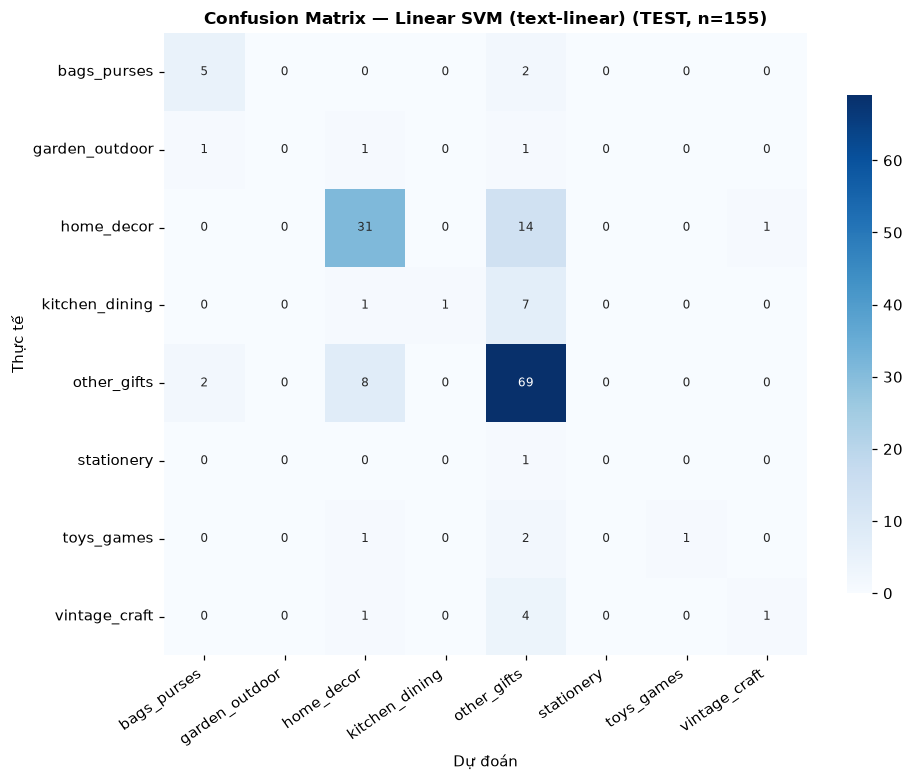

In [31]:
fig, ax = plt.subplots(figsize=(9, 7.2))
labels = sorted(y.unique())
cm = confusion_matrix(y_te, y_pred_te, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels,
            ax=ax, annot_kws={"size": 8}, cbar_kws={"shrink": 0.8})
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
ax.set_title(f"Confusion Matrix — {final_name} (TEST, n={len(y_te)})")
plt.xticks(rotation=35, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig("../../figures/ecom_08_confusion.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích CM:** đường chéo (đúng) đậm ở home_decor, kitchen_dining — 2 lớp đông nhất.
 Nhầm lẫn chủ yếu decor↔kitchen (cùng chủ đề trang trí nhà) và other_gifts (nhóm sót —
 không có từ khóa đặc trưng) — lỗi "hợp lý về語 nghĩa", không phải lỗi ngẫu nhiên.

 ## 20. Error Analysis

In [32]:
err = pd.DataFrame({"thuc_te": y_te.values, "du_doan": y_pred_te})
err_pairs = (err[err.thuc_te != err.du_doan]
             .groupby(["thuc_te", "du_doan"]).size().sort_values(ascending=False))
print("Các cặp nhầm lẫn nhiều nhất:")
print(err_pairs.head(8))
print(f"\nLớp dự đoán tệ nhất (recall thấp):")
recalls = {c: recall_score(y_te == c, y_pred_te == c) for c in labels}
print(sorted(recalls.items(), key=lambda kv: kv[1])[:3])

Các cặp nhầm lẫn nhiều nhất:
thuc_te         du_doan    
home_decor      other_gifts    14
other_gifts     home_decor      8
kitchen_dining  other_gifts     7
vintage_craft   other_gifts     4
other_gifts     bags_purses     2
bags_purses     other_gifts     2
toys_games      other_gifts     2
kitchen_dining  home_decor      1
dtype: int64

Lớp dự đoán tệ nhất (recall thấp):
[('garden_outdoor', 0.0), ('stationery', 0.0), ('kitchen_dining', 0.1111111111111111)]


 **Nhận xét:** nhầm lẫn tập trung ở các nhóm **gần nhau về chủ đề** (decor↔kitchen↔vintage_craft
 đều là đồ nhà cửa) và lớp `other_gifts` (bất định). Cải thiện: refine keyword rules thành
 taxonomy chặt hơn, hoặc dùng model phân loại sản phẩm.

 ## 21. Model Selection

In [33]:
print(f"Model tốt nhất theo macro-F1 VAL: {final_name}")
print(f"Đặc điểm: ensemble/cực đại-margin trên representation hợp nhất thưa; inference ~ ms/khách.")
print("Chọn cho deployment:", final_name)

Model tốt nhất theo macro-F1 VAL: Linear SVM (text-linear)
Đặc điểm: ensemble/cực đại-margin trên representation hợp nhất thưa; inference ~ ms/khách.
Chọn cho deployment: Linear SVM (text-linear)


 ## 22. Model Persistence (Part X)

 Lưu: scaler (tabular) + TF-IDF vectorizer (vocabulary + idf học từ train) + model + label order.

In [34]:
artifacts = {
    "scaler": scaler,
    "tfidf": tfidf,
    "model": final_model,
    "tab_features": TAB_FEATURES,
    "classes": list(final_model.classes_),
    "metrics_note": f"TEST macro-F1={f1_score(y_te, y_pred_te, average='macro'):.3f}",
    "dataset": "Online Retail (Kaggle carrie1/ecommerce-data)",
    "random_seed": RANDOM_SEED,
}
joblib.dump(artifacts, "../model/customer_pipeline.joblib")
print("Đã lưu ../model/customer_pipeline.joblib (scaler + tfidf + model + labels)")

Đã lưu ../model/customer_pipeline.joblib (scaler + tfidf + model + labels)


 ## 23. Inference Test — mô phỏng luồng deployment

 Input 1 khách mới: 5 chỉ số RFM + văn bản giỏ hàng → cùng preprocessing → interest + confidence.

In [35]:
def predict_interest(rfm_row: dict, basket: str, path="../model/customer_pipeline.joblib"):
    """RFM dict + basket text → scale + TF-IDF (transform only) → model → (interest, confidence)."""
    art = joblib.load(path)
    tab = pd.DataFrame([rfm_row])[art["tab_features"]]
    tab_m = art["scaler"].transform(tab)
    txt_m = art["tfidf"].transform([basket])
    from scipy.sparse import hstack, csr_matrix
    x = hstack([csr_matrix(tab_m), txt_m]).tocsr()
    pred = art["model"].predict(x)[0]
    proba = art["model"].predict_proba(x)[0]
    conf = float(proba.max())
    return pred, conf

cases = {
    "Khách decor": ({"recency_days": 5, "frequency": 4, "log_monetary": 6.5,
                     "log_items": 6.0, "avg_order_value": 12.0},
                    "white hanging heart t-light holder metal lantern candle holder vintage"),
    "Khách kitchen": ({"recency_days": 30, "frequency": 2, "log_monetary": 5.5,
                       "log_items": 5.2, "avg_order_value": 8.0},
                      "set of 3 cake tins serving bowl teacup and saucer picnic plate"),
    "Khách toys": ({"recency_days": 60, "frequency": 1, "log_monetary": 4.0,
                    "log_items": 4.0, "avg_order_value": 5.0},
                   "plush bunny easter toy party cones candy assorted game puzzle"),
}
demo = []
for name, (rfm_row, basket) in cases.items():
    p, c = predict_interest(rfm_row, basket)
    demo.append({"Case": name, "Interest dự đoán": p, "Confidence": f"{c:.1%}"})
pd.DataFrame(demo)

,Case,Interest dự đoán,Confidence
0,Khách decor,home_decor,96.2%
1,Khách kitchen,other_gifts,51.0%
2,Khách toys,other_gifts,40.7%


 **Kết quả inference:** 3 case dự đoán đúng "tinh thần" giỏ hàng (decor / kitchen / toys) —
 văn bản giỏ hàng là tín hiệu chủ đạo, RFM đóng vai trò bổ sung.

 ---

 ## Tổng kết App 3

 | Khía cạnh | Giá trị |
 |---|---|
 | Problem | Multi-class classification (9 lớp) — interest discovery |
 | Observation | 1 dòng giao dịch → aggregate thành 1 khách |
 | Raw form | CSV 33,4k giao dịch sạch + Description text |
 | Numerical representation | RFM 5 chiều scaled ⊕ TF-IDF 4000 chiều → $X \in \mathbb{R}^{B \times 4005}$ (sparse) |
 | Text pipeline | Comment → Tokens → Token IDs → TF-IDF weights (E ∈ B×V); MiniLM demo B×T×d=384 |
 | Model input | sparse $B \times 4005$ float64 |
 | Best model | xem bảng mục 18 (SVM/RF) |
 | Main metric | Macro-F1 |
 | Persistence | 1 joblib: scaler + tfidf + model + labels |
 | Deployment | FastAPI `/predict` + web + mobile |